In [4]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [5]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

In [6]:
data_dir

'.\\datasets\\flower_photos'

In [7]:
import pathlib
data_dir=pathlib.Path(data_dir)/'flower_photos'
data_dir

WindowsPath('datasets/flower_photos/flower_photos')

In [8]:
list(data_dir.glob('*/*.jpg'))[:5]

[WindowsPath('datasets/flower_photos/flower_photos/daisy/100080576_f52e8ee070_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10140303196_b88d3d6cec.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172379554_b296050f82_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172567486_2748826a8b.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/daisy/10172636503_21bededa75_n.jpg')]

In [9]:
image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

3670


In [10]:
roses = list(data_dir.glob('roses/*'))
roses[:5]

[WindowsPath('datasets/flower_photos/flower_photos/roses/10090824183_d02c613f10_m.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/102501987_3cdb8e5394_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10503217854_e66a804309.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/10894627425_ec76bbc757_n.jpg'),
 WindowsPath('datasets/flower_photos/flower_photos/roses/110472418_87b6a3aa98_m.jpg')]

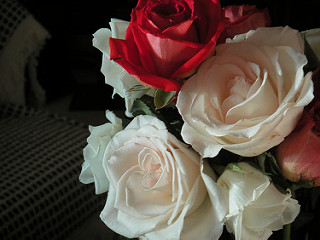

In [11]:
PIL.Image.open(str(roses[1]))

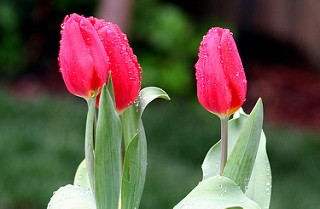

In [12]:
tulips = list(data_dir.glob('tulips/*'))
PIL.Image.open(str(tulips[0]))

In [13]:
flowers_images_dict = {
    'roses': list(data_dir.glob('roses/*.jpg')),
    'daisy': list(data_dir.glob('daisy/*.jpg')),
    'dandelion': list(data_dir.glob('dandelion/*.jpg')),
    'sunflowers': list(data_dir.glob('sunflowers/*.jpg')),
    'tulips': list(data_dir.glob('tulips/*.jpg')),
}

In [14]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [15]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [16]:
img.shape

(240, 179, 3)

In [17]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [18]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [19]:
X=np.array(X)
y=np.array(y)

In [20]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [21]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [22]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)         

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 431ms/step - accuracy: 0.4709 - loss: 1.2509
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 389ms/step - accuracy: 0.6090 - loss: 0.9969
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 31s 365ms/step - accuracy: 0.6642 - loss: 0.8540
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 491ms/step - accuracy: 0.7478 - loss: 0.6792
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 48s 559ms/step - accuracy: 0.8136 - loss: 0.4972
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 45s 516ms/step - accuracy: 0.8870 - loss: 0.3289
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 37s 432ms/step - accuracy: 0.9386 - loss: 0.1898
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 45s 480ms/step - accuracy: 0.9640 - loss: 0.1102
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 43s 503ms/step - accuracy: 0.9840 - loss: 0.0552
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 42s 484ms/step - accuracy: 0.9931 - loss: 0.0351
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 463ms/step - accuracy: 0.9909 - loss: 0.0363
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 59

In [23]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.6830 - loss: 2.1109


[2.1108615398406982, 0.6830065250396729]

In [24]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 78ms/step


array([[  2.896243  ,  28.857952  ,  -5.5594363 , -18.90355   ,
         -4.5921426 ],
       [ 10.862754  ,   0.03484277,  -4.447773  ,  -7.931005  ,
          4.607133  ],
       [ -2.9491718 ,   2.7087827 ,  14.99392   , -14.886066  ,
         -2.0289664 ],
       ...,
       [  1.4500291 ,  -5.49518   ,  -4.8371487 ,   9.836475  ,
          0.5354098 ],
       [  6.099356  ,  -1.4390631 ,   7.4753475 ,  -4.23679   ,
         -2.3126042 ],
       [ -4.4783506 , -14.853563  ,  -0.20054874,   7.9754066 ,
          5.537491  ]], shape=(918, 5), dtype=float32)

In [25]:
score = tf.nn.softmax(predictions[0])

In [26]:
np.argmax(score)

np.int64(1)

In [27]:
y_test[0]

np.int64(1)

In [28]:
data_augmentation = keras.Sequential([
    layers.Input(shape=(180,180, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

In [29]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])
              
model.fit(X_train_scaled, y_train, epochs=30)   

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 35s 307ms/step - accuracy: 0.4542 - loss: 1.2935
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 298ms/step - accuracy: 0.5890 - loss: 1.0300
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 283ms/step - accuracy: 0.6472 - loss: 0.9079
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step - accuracy: 0.6791 - loss: 0.8430
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 277ms/step - accuracy: 0.7020 - loss: 0.7905
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 278ms/step - accuracy: 0.7173 - loss: 0.7377
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 26s 297ms/step - accuracy: 0.7217 - loss: 0.7131
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 284ms/step - accuracy: 0.7511 - loss: 0.6574
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 25s 288ms/step - accuracy: 0.7522 - loss: 0.6491
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 40s 278ms/step - accuracy: 0.7555 - loss: 0.6359
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 24s 274ms/step - accuracy: 0.7823 - loss: 0.5755
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 41

In [30]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7440 - loss: 0.9602


[0.9601667523384094, 0.7440087199211121]